In [2]:
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

warnings.filterwarnings('ignore')

In [3]:
churn= pd.read_csv(r'C:\Users\suraj\Downloads\Bank_Customer_Churn.csv')
churn.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
churn.shape

(10000, 12)

In [5]:
churn.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [6]:
churn.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [7]:
churn['churn'].value_counts()

churn
0    7656
1    2344
Name: count, dtype: int64

<Axes: title={'center': 'Distribution of churn'}, xlabel='churn', ylabel='frequency'>

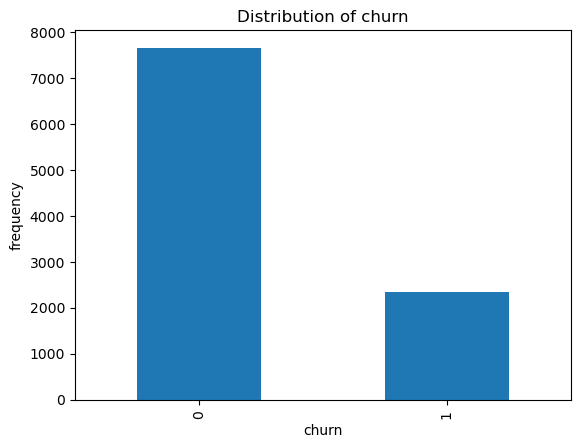

In [8]:
churn['churn'].value_counts().plot(kind='bar',xlabel='churn',ylabel='frequency',title='Distribution of churn')

# Segregating target and input fields

In [9]:
not_important= 'customer_id'
target_field= 'churn'
fields= list(churn.columns)
fields.remove(target_field)
fields.remove(not_important)
input_fields= fields



# Segregating numeric and non-numeric input fields

In [10]:
category_fields= list(churn[input_fields].select_dtypes(exclude='number').columns)
numeric_fields= list(churn[input_fields].select_dtypes(include='number').columns)
numeric_fields

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

# Splitting dataset into training and test data

In [11]:
training_data,test_data= train_test_split(churn,test_size=0.3,random_state=4)

# Scaling numeric fields using RobustScaler

In [12]:
scaler= RobustScaler().fit(training_data[numeric_fields])
training_data.loc[:,numeric_fields]= scaler.transform(training_data[numeric_fields])
test_data.loc[:,numeric_fields]= scaler.transform(test_data[numeric_fields])

# Encoding categorical fields

In [13]:
encoder= OneHotEncoder().fit(training_data[category_fields])
training_data.loc[:,encoder.get_feature_names_out()]= encoder.transform(training_data[category_fields]).toarray()
test_data.loc[:,encoder.get_feature_names_out()]= encoder.transform(test_data[category_fields]).toarray()

In [14]:
#modifying list of input fields after encoding
input_fields= list(encoder.get_feature_names_out())+numeric_fields

In [15]:
model= LogisticRegression().fit(training_data[input_fields],training_data[target_field])
predictions=model.predict(test_data[input_fields])

# Evaluating the model

In [16]:
print(f'accuracy_score:{accuracy_score(test_data[target_field], predictions)}')
print(f'precision_score:{precision_score(test_data[target_field], predictions)}')
print(f'sensivity_score:{recall_score(test_data[target_field], predictions)}')
print(f'f1_score:{f1_score(test_data[target_field], predictions)}')

accuracy_score:0.7733333333333333
precision_score:0.5882352941176471
sensivity_score:0.21978021978021978
f1_score:0.32


In [17]:
model.coef_

array([[-0.65035497,  0.32899626, -0.66555117, -0.50037226, -0.48653762,
         0.05655411,  0.85906877, -0.07330398,  0.55018539,  0.02430909,
        -0.00207254, -0.91146521, -0.01281783]])

In [18]:
#storing weights in a dataframe
weights=pd.DataFrame({'features': model.feature_names_in_.reshape(-1),'weight': model.coef_.reshape(-1)})

#sorting features by their weights
weights.sort_values(by=['weight'],ascending=False)

,features,weight
6,age,0.859069
8,balance,0.550185
1,country_Germany,0.328996
5,credit_score,0.056554
9,products_number,0.024309
10,credit_card,-0.002073
12,estimated_salary,-0.012818
7,tenure,-0.073304
4,gender_Male,-0.486538
3,gender_Female,-0.500372


based on the above weights, we can conclude that the model is assigning more importance to age,balance,country,gender,active _member : the remaning
fields dont significantly imapct the model performance . so we can remove these fields from the input features.

In [17]:
traget_field='churn'
input_fields= ['age','balance','country','gender','active_member']

category_fields= list(churn[input_fields].select_dtypes(exclude='number').columns)
numeric_fields= list(churn[input_fields].select_dtypes(include='number').columns)

training_data,test_data= train_test_split(churn,test_size=0.3,random_state=4)

scaler= RobustScaler().fit(training_data[numeric_fields])
training_data.loc[:,numeric_fields]= scaler.transform(training_data[numeric_fields])
test_data.loc[:,numeric_fields]= scaler.transform(test_data[numeric_fields])

encoder= OneHotEncoder().fit(training_data[category_fields])
training_data.loc[:,encoder.get_feature_names_out()]= encoder.transform(training_data[category_fields]).toarray()
test_data.loc[:,encoder.get_feature_names_out()]= encoder.transform(test_data[category_fields]).toarray()

#modifying list of input fields after encoding
model_input_fields= list(encoder.get_feature_names_out())+numeric_fields

model= LogisticRegression().fit(training_data[model_input_fields],training_data[target_field])
predictions=model.predict(test_data[model_input_fields])

# Evaluating the model

In [18]:
print(f'accuracy: {accuracy_score(test_data[target_field], predictions)}')
print(f'precision: {precision_score(test_data[target_field], predictions)}')
print(f'recall: {recall_score(test_data[target_field], predictions)}')
print(f'f1: {f1_score(test_data[target_field], predictions)}')

accuracy: 0.7753333333333333
precision: 0.5978260869565217
recall: 0.22664835164835165
f1: 0.3286852589641434


# Saving the model for future use

In [19]:
import joblib as jb
churn_model= {'target_field': target_field
               ,'input_fields': input_fields
                ,'categorical_fields': category_fields
                 ,'numeric_fields': numeric_fields
                  ,'model_inputs': model_input_fields
                   ,'scaler': scaler
                    ,'encoder': encoder
                    ,'model': model}
jb.dump(churn_model, 'churn_model.joblib')

['churn_model.joblib']

In [ ]:
import joblib as jb
import pandas as pd

saved_model= jb.load('churn_model.joblib')
input_values={}
for feature in saved_model['input_fields']:
    value= input(f'enter the {feature.lower()}:')
    input_values.update({feature:value})

for field in saved_model['numeric_fields']:
    input_values[field]= float(input_values[field])
    
input_record= pd.DataFrame(input_values, index=[0])

input_record[saved_model['numeric_fields']]= saved_model['scaler'].transform(input_record[saved_model['numeric_fields']])

input_record.loc[:,saved_model['encoder'].get_feature_names_out()]= saved_model['encoder'].transform(input_record[saved_model['categorical_fields']]).toarray()

if saved_model['model'].predict(input_record[saved_model['model_inputs']]) == [1]:
    prediction= 'churn'
else:
    prediction= 'wont_churn'
print(f'pridicted_status:{prediction}')

